## NB1 — Initial conditions: U=0.2, slope WIDTH varies (test160–test239)

**What changes:** slope physical width 5–100 km (50–1000 cells at 100 m res), for 4 jet widths  
**Fixed:** U=0.2 m/s, Yj=200 km, slope height=400 m (shelf 100 m → basin 500 m)  
**dx=100 m, Lx=500 km, Ly=400 km**

| Exp | Ljet | U | Slope width | Height |
|-----|------|---|-------------|--------|
| 160 | 5 | 0.2 | 5 km (50 cells) | 400 m |
| 170 | 5 | 0.2 | 55 km (550 cells) | 400 m |
| 180 | 10 | 0.2 | 5 km (50 cells) | 400 m |
| 190 | 10 | 0.2 | 55 km (550 cells) | 400 m |
| 200 | 15 | 0.2 | 5 km (50 cells) | 400 m |
| 210 | 15 | 0.2 | 55 km (550 cells) | 400 m |
| 220 | 20 | 0.2 | 5 km (50 cells) | 400 m |
| 230 | 20 | 0.2 | 55 km (550 cells) | 400 m |
*(every 10th shown)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

### Domain, grid and physical constants

In [2]:
# ── Domain (fixed for all experiments) ───────────────────────────────────────
Lx = 500e3    # m   500 km
Ly = 400e3    # m   400 km
dx = 300      # m
dy = 300      # m
nx = int(Lx / dx)   # 5000
ny = int(Ly / dy)   # 4000
nxp = nx + 1
nyp = ny + 1

xh = np.linspace(dx/2, nx*dx - dx/2, nx)
yh = np.linspace(dy/2, ny*dy - dy/2, ny)
xq = np.linspace(0, nx*dx, nxp)
yq = np.linspace(0, ny*dy, nyp)

# Physical constants
f = -1e-5   # s^-1
g = 9.81    # m s^-2

# Bathymetry constants
shallow_depth = 100.0   # m  shelf
deep_depth    = 500.0   # m  basin
Ys            = 200e3   # m  slope centre

print(f'Grid: nx={nx}, ny={ny}  |  Domain: {Lx/1e3:.0f} x {Ly/1e3:.0f} km  |  dx={dx} m')

Grid: nx=5000, ny=4000  |  Domain: 500 x 400 km  |  dx=100 m


### Helper functions (velocity, bathymetry, NetCDF writer)

In [3]:
def make_fields(Yj, Ljet, U):
    """Velocity and eta fields for given jet parameters."""
    Xq_, Yh_u = np.meshgrid(xq, yh)
    Xh_, Yh_h = np.meshgrid(xh, yh)
    yprime_u   = (Yh_u - Yj) / Ljet
    yprime_h   = (Yh_h - Yj) / Ljet
    u_clean    = U * np.tanh(yprime_u)
    v          = np.zeros((nyp, nx))
    rng        = np.random.default_rng(seed=42)
    noise      = rng.standard_normal(u_clean.shape)
    decay      = 1.0 / np.cosh(yprime_u)**2
    u          = u_clean + 1e-3 * decay * noise
    eta_t      = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
    eta_t     -= eta_t.mean()
    return u, v, eta_t


def make_bathy(slope_width_cells, slope_height_m):
    """2-D bathymetry. Slope centred at Ys.
    Even width -> centre on cell int(Ys/dy).
    Odd  width -> centre on cell int(Ys/dy)+1.
    Basin depth = shallow_depth + slope_height_m.
    """
    basin      = shallow_depth + slope_height_m
    c_idx      = int(Ys/dy) if slope_width_cells % 2 == 0 else int(Ys/dy) + 1
    ss         = c_idx - slope_width_cells // 2
    se         = ss + slope_width_cells
    profile    = np.zeros(ny)
    profile[:ss]   = shallow_depth
    profile[ss:se] = np.linspace(shallow_depth, basin, slope_width_cells)
    profile[se:]   = basin
    return np.tile(profile[:, np.newaxis], (1, nx)), ss, se


def write_netcdf(input_dir, u, v, eta_t, depth_2d):
    """Write init_vel.nc, init_eta.nc, ocean_topog.nc."""
    zl   = 1
    z    = np.array([-250.0])
    u_3d = u    [np.newaxis, :, :]
    v_3d = v    [np.newaxis, :, :]
    h_3d = eta_t[np.newaxis, :, :]

    # init_vel.nc
    nc = Dataset(os.path.join(input_dir, 'init_vel.nc'), 'w', format='NETCDF4')
    for dim, sz in [('zl',zl),('yh',ny),('xh',nx),('yq',nyp),('xq',nxp)]:
        nc.createDimension(dim, sz)
    for name, data, dims in [('zl',z,('zl',)),('xh',xh,('xh',)),
                               ('yh',yh,('yh',)),('xq',xq,('xq',)),('yq',yq,('yq',))]:
        v0=nc.createVariable(name,'f4',dims); v0[:]=data
    nc['zl'].axis='Z'; nc['zl'].long_name='depth to layer'
    for n_ in ['xh','xq']:
        nc[n_].axis='X'; nc[n_].long_name=f'{n_[1]}-point longitude'; nc[n_].units='meters'
    for n_ in ['yh','yq']:
        nc[n_].axis='Y'; nc[n_].long_name=f'{n_[1]}-point latitude';  nc[n_].units='meters'
    uv=nc.createVariable('u','f4',('zl','yh','xq')); uv[:]=u_3d
    uv.units='m s-1'; uv.long_name='Eastward velocity'
    uv.standard_name='eastward_sea_water_velocity'
    vv=nc.createVariable('v','f4',('zl','yq','xh')); vv[:]=v_3d
    vv.units='m s-1'; vv.long_name='Northward velocity'
    vv.standard_name='northward_sea_water_velocity'
    nc.regrid_method='bilinear'; nc.close()

    # init_eta.nc
    nc = Dataset(os.path.join(input_dir, 'init_eta.nc'), 'w', format='NETCDF4')
    nc.createDimension('yh', ny); nc.createDimension('xh', nx)
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.axis='X'; v0.long_name='h-point longitude'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.axis='Y'; v0.long_name='h-point latitude';  v0.units='meters'
    hv=nc.createVariable('eta_t','f4',('yh','xh')); hv[:]=h_3d
    hv.units='m'; hv.long_name='Free surface height anomaly'
    hv.standard_name='sea_floor_depth_below_sea_surface'; nc.close()

    # ocean_topog.nc
    nc = Dataset(os.path.join(input_dir, 'ocean_topog.nc'), 'w', format='NETCDF4')
    nc.createDimension('yh', ny); nc.createDimension('xh', nx)
    v0=nc.createVariable('xh','f4',('xh',)); v0[:]=xh
    v0.long_name='t-cell center x-location'; v0.units='meters'
    v0=nc.createVariable('yh','f4',('yh',)); v0[:]=yh
    v0.long_name='t-cell center y-location'; v0.units='meters'
    dv=nc.createVariable('depth','f4',('yh','xh')); dv[:]=depth_2d
    dv.units='m'; dv.long_name='ocean bottom depth'
    dv.standard_name='sea_floor_depth_below_geoid'; nc.close()

### Experiment definitions

In [4]:
base_dir = '/scratch/nm03/ae7501/mom6_input_directories/idealized'

# slope widths: physical km and equivalent cells at dx=100m
slope_widths_km    = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
slope_widths_cells = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]   # = [w*10 for w in slope_widths_km]
fixed_height_m     = 400.0       # m  (shelf 100m -> basin 500m)
Yj_default         = Ly / 2                # 200 km

experiments = []
for Ljet_km in [5, 10, 15, 20]:
    Ljet = Ljet_km * 1e3
    for w_cells, w_km in zip(slope_widths_cells, slope_widths_km):
        experiments.append(dict(
            exp_num       = len(experiments) + 160,
            Ljet          = Ljet,
            Ljet_km       = Ljet_km,
            U             = 0.2,
            Yj            = Yj_default,
            slope_w_cells = w_cells,
            slope_w_km    = w_km,
            slope_h_m     = fixed_height_m))

print(f'{len(experiments)} experiments: test{experiments[0]["exp_num"]} – test{experiments[-1]["exp_num"]}')

80 experiments: test160 – test239


### Main loop

In [5]:
cached_key, cached_fields = None, None

for exp in experiments:
    exp_name  = f'test{exp["exp_num"]}'
    input_dir = os.path.join(base_dir, exp_name, 'INPUT')
    os.makedirs(input_dir, exist_ok=True)

    vel_key = (exp['Ljet'], exp['U'], exp['Yj'])
    if vel_key != cached_key:
        cached_fields = make_fields(exp['Yj'], exp['Ljet'], exp['U'])
        cached_key    = vel_key

    u, v, eta_t = cached_fields
    depth_2d, ss, se = make_bathy(exp['slope_w_cells'], exp['slope_h_m'])
    write_netcdf(input_dir, u, v, eta_t, depth_2d)

    print(f'{exp_name}: Ljet={exp["Ljet_km"]}km  W={exp["slope_w_km"]}km '
          f'({exp["slope_w_cells"]}cells)  slope=[{ss},{se})  -> {input_dir}')

print(f"\n{'='*60}\nDone. {len(experiments)} experiments written.\n{'='*60}")

test160: Ljet=5km  W=5km (50cells)  slope=[1975,2025)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test160/INPUT
test161: Ljet=5km  W=10km (100cells)  slope=[1950,2050)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test161/INPUT
test162: Ljet=5km  W=15km (150cells)  slope=[1925,2075)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test162/INPUT
test163: Ljet=5km  W=20km (200cells)  slope=[1900,2100)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test163/INPUT
test164: Ljet=5km  W=25km (250cells)  slope=[1875,2125)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test164/INPUT
test165: Ljet=5km  W=30km (300cells)  slope=[1850,2150)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test165/INPUT
test166: Ljet=5km  W=35km (350cells)  slope=[1825,2175)  -> /scratch/nm03/ae7501/mom6_input_directories/idealized/test166/INPUT
test167: Ljet=5km  W=40km (400cells)  slope=[1800,2200)  -> /scratch/nm03/ae7501/mom6_input_directories/id

### plot — bathymetry profiles (zoomed around slope)

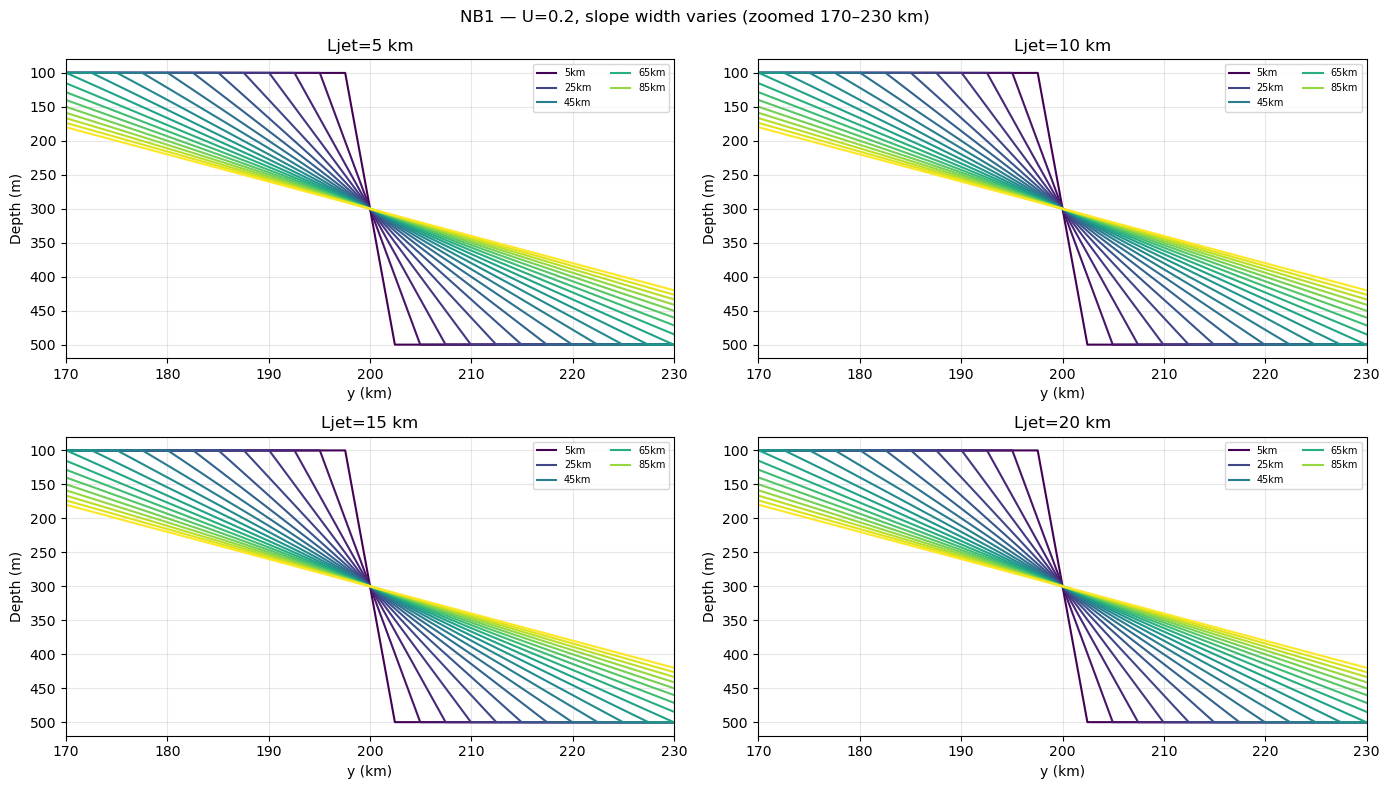

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, Ljet_km in zip(axes.flat, [5, 10, 15, 20]):
    sub = [e for e in experiments if e['Ljet_km'] == Ljet_km]
    colors = plt.cm.viridis(np.linspace(0, 1, len(sub)))
    for i, exp in enumerate(sub):
        d2d, ss, se = make_bathy(exp['slope_w_cells'], exp['slope_h_m'])
        ax.plot(yh/1e3, d2d[:,0], color=colors[i],
                label=f'{exp["slope_w_km"]}km' if i % 4 == 0 else '')
    ax.set_xlim(170, 230); ax.invert_yaxis()
    ax.set_title(f'Ljet={Ljet_km} km'); ax.set_xlabel('y (km)'); ax.set_ylabel('Depth (m)')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
plt.suptitle('NB1 — U=0.2, slope width varies (zoomed 170–230 km)', fontsize=12)
plt.tight_layout(); plt.show()